In [1]:
pip install ultralytics opencv-python matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


In [7]:
# Step 2: Import libraries
import cv2
import numpy as np
from ultralytics import YOLO
import matplotlib.pyplot as plt

100%|█████████████████████████████████████████████████████████████████████████████| 6.25M/6.25M [00:03<00:00, 1.79MB/s]



0: 448x640 1 person, 6 cars, 1 truck, 4 traffic lights, 399.6ms
Speed: 20.3ms preprocess, 399.6ms inference, 26.0ms postprocess per image at shape (1, 3, 448, 640)


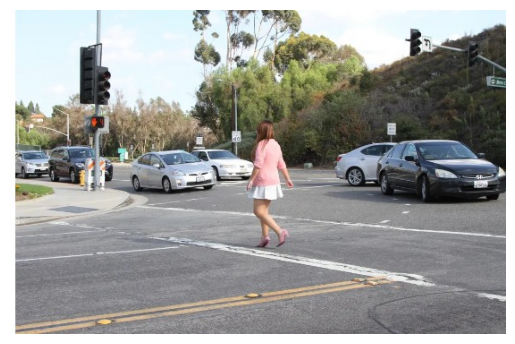

In [11]:
# Step 2: Import libraries
import cv2
import numpy as np
from ultralytics import YOLO
import matplotlib.pyplot as plt


# Step 3: Object Detection Function
def detect_objects(image_path):
    """
    Detect objects in an image using YOLOv8.
    """

    # Load YOLO model (pre-trained)
    model = YOLO('yolov8n.pt')

    # Read image
    image = cv2.imread(image_path)

    if image is None:
        print("❌ Image not found. Check path.")
        return

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Perform detection
    results = model(image_rgb)[0]

    # Copy image for drawing
    annotated_image = image_rgb.copy()

    # Generate random colors
    np.random.seed(42)
    colors = np.random.randint(0, 255, size=(100, 3), dtype=np.uint8)

    # Get detected boxes
    boxes = results.boxes

    return boxes, results.names, annotated_image, colors


# ✅ Call function AFTER defining it
boxes, names, annotated_image, colors = detect_objects('test.jpg')


# ✅ (Optional) Display image
plt.imshow(annotated_image)
plt.axis('off')
plt.show()

In [17]:
# Step 4: Draw Bounding Boxes

for box in boxes:
    # Get coordinates
    x1, y1, x2, y2 = map(int, box.xyxy[0])

    # Confidence score
    confidence = float(box.conf[0])

    # Class ID and name
    class_id = int(box.cls[0])
    class_name = names[class_id]

    # Draw rectangle
    cv2.rectangle(annotated_image, (x1, y1), (x2, y2), (0, 255, 0), 2)

    # Put label
    label = f"{class_name} {confidence:.2f}"
    cv2.putText(annotated_image, label,
                (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5, (0, 255, 0), 2)

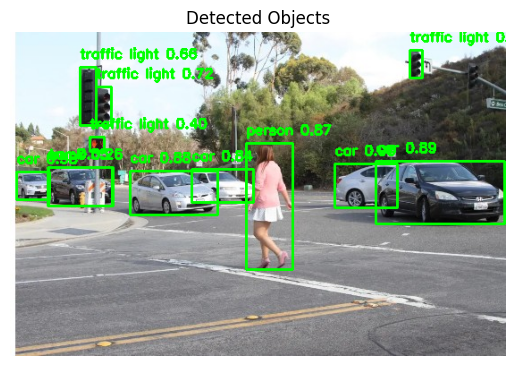

In [18]:
# STEP 5: Show final image (with detections)
plt.imshow(annotated_image)
plt.axis('off')
plt.title("Detected Objects")
plt.show()